In [12]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
import importlib
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
warnings.filterwarnings('ignore')

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.linear_model import LinearRegression,Ridge,Lasso, ElasticNet
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [3]:
trainset = h5py.File("../drive/MyDrive/vscode-ssh/GIZ_Biomass/data/09072022_1154_train.h5", "r")
validateset = h5py.File("../drive/MyDrive/vscode-ssh/GIZ_Biomass/data/09072022_1154_val.h5", "r")
testset = h5py.File("../drive/MyDrive/vscode-ssh/GIZ_Biomass/data/09072022_1154_test.h5", "r")

In [4]:
# attributes of trainset
trainset.keys()

<KeysViewHDF5 ['agbd', 'cloud', 'images', 'lat', 'lon', 'scl']>

# Prediction using CNN

In [4]:
# train
train_images = np.array(trainset['images'],dtype=np.float64)
train_biomasses = np.array(trainset['agbd'],dtype=np.float64).reshape(-1, 1)

# validate
validate_images = np.array(validateset['images'],dtype=np.float64)
validate_biomasses = np.array(validateset['agbd'],dtype=np.float64).reshape(-1, 1)

# test 
test_images = np.array(testset['images'],dtype=np.float32)
test_biomasses = np.array(testset['agbd'],dtype=np.float32).reshape(-1, 1)

In [5]:
class CustomScaler(BaseEstimator, TransformerMixin):
  
  def fit(self, X, y=None):
    self.mean = np.mean(X, axis=(0,1,2))
    self.std = np.std(X, axis=(0,1,2))
    return self

  def transform(self, X, y=None):
    return (X-self.mean[None,None,None,:])/self.std[None,None,None,:] 

  def reverse_transform(self):
    return None

scaler = CustomScaler()
train_images = scaler.fit_transform(train_images)
validate_images = scaler.transform(validate_images)
test_images = scaler.transform(test_images)

scaler = StandardScaler()
train_biomasses = scaler.fit_transform(train_biomasses)
validate_biomasses = scaler.transform(validate_biomasses)
test_biomasses = scaler.transform(test_biomasses)

In [10]:
model = models.Sequential([
    layers.Input(shape=(15, 15, 12)),

    layers.Conv2D(filters=32, kernel_size = [3, 3], activation='relu'),
    layers.Conv2D(filters=64, kernel_size = [3, 3], activation='relu'),
    layers.Conv2D(filters=128, kernel_size = [3, 3], activation='relu'),
    layers.Conv2D(filters=128, kernel_size = [3, 3], activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),

    layers.Dense(1, activation="linear")
])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_14 (Conv2D)          (None, 13, 13, 32)        3488      
                                                                 
 conv2d_15 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 conv2d_16 (Conv2D)          (None, 9, 9, 128)         73856     
                                                                 
 conv2d_17 (Conv2D)          (None, 7, 7, 128)         147584    
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 3, 3, 128)        0         
 2D)                                                             
                                                                 
 flatten_3 (Flatten)         (None, 1152)              0         
                                                      

In [11]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

history = model.fit(
    x = train_images,
    y = train_biomasses,
    validation_data=(validate_images, validate_biomasses),
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.TensorBoard(
            './logs', update_freq=1
        )
    ]
)

Epoch 1/100
783/783 [==============================] - ETA: 0s - loss: 0.9369 - root_mean_squared_error: 0.9679

# Dimension reduction 

## Preprocessing

In [5]:
# train
train_images = np.array(trainset['images'],dtype=np.float64)
train_biomasses = np.array(trainset['agbd'],dtype=np.float64).reshape(-1, 1)

# validate
validate_images = np.array(validateset['images'],dtype=np.float64)
validate_biomasses = np.array(validateset['agbd'],dtype=np.float64).reshape(-1, 1)

# test 
test_images = np.array(testset['images'],dtype=np.float32)
test_biomasses = np.array(testset['agbd'],dtype=np.float32).reshape(-1, 1)

In [6]:
class CustomScaler(BaseEstimator, TransformerMixin):
  
  def fit(self, X, y=None):
    self.mean = np.mean(X, axis=(0,1,2))
    self.std = np.std(X, axis=(0,1,2))
    return self

  def transform(self, X, y=None):
    return (X-self.mean[None,None,None,:])/self.std[None,None,None,:] 

  def reverse_transform(self):
    return None

class FlattenTransformer(BaseEstimator, TransformerMixin):

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    return X.reshape((X.shape[0], -1))

## PCA

In [7]:
flattened_train_images = FlattenTransformer().fit_transform(train_images)

pca = PCA()
pca.fit(flattened_train_images)
print(pca.explained_variance_ratio_)

[5.25272213e-01 1.33634104e-01 7.28961197e-02 ... 3.47517133e-11
 3.36118976e-11 2.20208124e-11]


In [12]:
ratio_ = 0
for n_components in range(pca.explained_variance_ratio_.shape[0]):
    ratio_ += pca.explained_variance_ratio_[n_components]
    if ratio_ > 0.99:
        break
n_components += 1
print("PCA allows  to reduce to {} variables".format(n_components))

PCA allows  to reduce to 112 variables


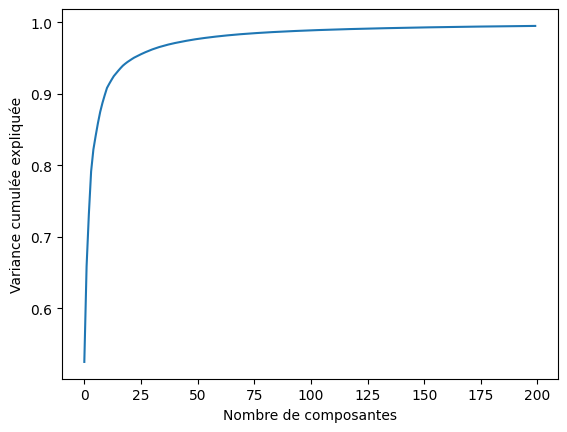

In [9]:
# Visualiser le pourcentage de variance expliquée cumulé
plt.plot(np.cumsum(pca.explained_variance_ratio_[:200]))
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée expliquée')
plt.show()


In [13]:
acp_pipeline = Pipeline(steps=[ ("scaler", CustomScaler()),
                                ("flatten", FlattenTransformer()),
                                ("pca", PCA(n_components=n_components)),
                                ("regressor", LinearRegression())
])
acp_pipeline.fit(train_images, train_biomasses)

Pipeline(steps=[('scaler', CustomScaler()), ('flatten', FlattenTransformer()),
                ('pca', PCA(n_components=112)),
                ('regressor', LinearRegression())])

In [19]:
pred_validation = acp_pipeline.predict(validate_images)
mse = mean_squared_error(validate_biomasses , pred_validation) 
rmse = np.sqrt(mse)
rmse

62.14924577710046

## Non-negative Matrix Factorization

In [8]:
flattened_train_images = FlattenTransformer().fit_transform(train_images)

for n_components in range(1, 300, 10):
    # Initialiser le modèle NMF avec le nombre de composantes actuel
    model = NMF(n_components=n_components)
    
    train_images_transformed = model.fit_transform(flattened_train_images)
    train_images_pred = model.inverse_transform(train_images_transformed)
    r2 = r2_score(flattened_train_images, train_images_pred)
    print("R² score for {} components: {}".format(n_components, r2))

R² score for 1 components: 0.4143762941167302
R² score for 11 components: 0.5733648166003928
R² score for 21 components: 0.6701031167334048
R² score for 31 components: 0.6746760998209945
R² score for 41 components: 0.6582624074353329
R² score for 51 components: 0.6287988377567472
R² score for 61 components: 0.6563538024233949
R² score for 71 components: 0.6492686794551898
R² score for 81 components: 0.641477982362232
R² score for 91 components: 0.6472389214881898
R² score for 101 components: 0.6282175347104971
R² score for 111 components: 0.6216211576724383
R² score for 121 components: 0.6370898457826375
R² score for 131 components: 0.6236549471681783
R² score for 141 components: 0.6133230068983238
R² score for 151 components: 0.6286896048797382
R² score for 161 components: 0.6098832262729591
R² score for 171 components: 0.6014598730594954
R² score for 181 components: 0.6161367287540435
R² score for 191 components: 0.6129658320625999
R² score for 201 components: 0.6132970390498843
R² s

# Exploration after Dimension reduction

In [10]:
# Initiaze the hyperparameters for each dictionary
param1 = {}
param1['regressor'] = [LinearRegression()]

param2 = {}
param2['regressor__alpha'] = [0.1, 0.5, 1]
param2['regressor'] = [Ridge()]

param3 = {}
param3['regressor__alpha'] = [0.1, 0.5, 1]
param3['regressor'] = [Lasso()]

param4 = {}
param4['regressor__n_neighbors'] = [2,5,10,25,50]
param4['regressor'] = [KNeighborsRegressor()]

param5 = {}
param5['regressor__C'] = [10**-2, 10**-1, 10**0, 10**1, 10**2]
param5['regressor__epsilon'] = [0.0,0.2,0.5,1]
param5['regressor'] = [LinearSVR()]

param6 = {}
param6['regressor__alpha'] = [0.1, 0.5, 1]
param6['regressor'] = [ElasticNet()]

param7 = {}
param7['regressor__n_estimators'] = [50, 100, 200, 500]
param7['regressor'] = [RandomForestRegressor()]

param8 = {}
param8['regressor__learning_rate'] = [0.01, 0.02, 0.05, 0.1]
param7['regressor__n_estimators'] = [50, 100, 200, 500]
param8['regressor'] = [GradientBoostingRegressor()]


In [15]:
n_components = 112
grid_search_pipeline = Pipeline(steps=[
                    ("scaler", CustomScaler()),
                    ("flatten", FlattenTransformer()),
                    ("pca", PCA(n_components=n_components)),
                    ("regressor", LinearRegression())])
params = [param1, param2, param3, param4, param5, param6, param7, param8]

In [16]:
grid_search = GridSearchCV(grid_search_pipeline, params, cv=3, scoring='neg_mean_squared_error', verbose=3).fit(train_images,train_biomasses)

Fitting 3 folds for each of 43 candidates, totalling 129 fits
[CV 1/3] END ..regressor=LinearRegression();, score=-3076.883 total time=  14.2s
[CV 2/3] END ..regressor=LinearRegression();, score=-2908.995 total time=  14.9s
[CV 3/3] END ..regressor=LinearRegression();, score=-2837.286 total time=  10.8s
[CV 1/3] END regressor=Ridge(), regressor__alpha=0.1;, score=-3076.317 total time=  15.6s
[CV 2/3] END regressor=Ridge(), regressor__alpha=0.1;, score=-2907.714 total time=  12.6s
[CV 3/3] END regressor=Ridge(), regressor__alpha=0.1;, score=-2839.196 total time=  12.5s
[CV 1/3] END regressor=Ridge(), regressor__alpha=0.5;, score=-3076.761 total time=  15.7s
[CV 2/3] END regressor=Ridge(), regressor__alpha=0.5;, score=-2908.153 total time=  13.2s
[CV 3/3] END regressor=Ridge(), regressor__alpha=0.5;, score=-2836.197 total time=  11.4s
[CV 1/3] END regressor=Ridge(), regressor__alpha=1;, score=-3075.743 total time=  14.8s
[CV 2/3] END regressor=Ridge(), regressor__alpha=1;, score=-2910.22